# Loading ,Preparing ,  Cleanning the Data

In [19]:
import pandas as pd
#Load the Data
df = pd.read_csv("NFLX_yfinance.csv")

#Erase the first two rows
df = df.iloc[2:].copy()


#Change the Column Name
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
#Convert it to Date Format
df['Date'] = pd.to_datetime(df['Date'])

#The columns
cols = ['Close', 'High', 'Low', 'Open', 'Volume']
#Converting the columns into numeric columns
for col in cols:
    df[col] = pd.to_numeric(df[col])


#Sorting them by date
df = df.sort_values('Date').reset_index(drop=True)

#OUTPUT
df.describe()



,Date,Close,High,Low,Open,Volume
count,5961,5961.000000,5961.000000,5961.000000,5961.000000,5.961000e+03
mean,2014-03-25 06:41:58.369401088,19.814843,20.092718,19.521450,19.811342,1.485302e+08
min,2002-05-23 00:00:00,0.037286,0.041071,0.034643,0.037786,2.856000e+06
25%,2008-04-24 00:00:00,0.440571,0.448714,0.430143,0.438571,5.201600e+07
50%,2014-03-26 00:00:00,5.081000,5.194000,5.001429,5.085714,9.113700e+07
75%,2020-02-26 00:00:00,33.785999,34.241001,33.183998,33.723000,1.774710e+08
max,2026-01-30 00:00:00,133.912994,134.115005,132.121002,133.822998,3.234140e+09
std,NaN,27.859933,28.205467,27.491630,27.858355,1.821948e+08


# Descriptive Statistics with Visualizations

Closing Price Summary Statistics
count    5961.000000
mean       19.814843
std        27.859933
min         0.037286
25%         0.440571
50%         5.081000
75%        33.785999
max       133.912994
Name: Close, dtype: float64

Coefficient of Variation: 1.4060133326539854
Skewness: 1.7944921343845615
Kurtosis: 3.0168169415088486 



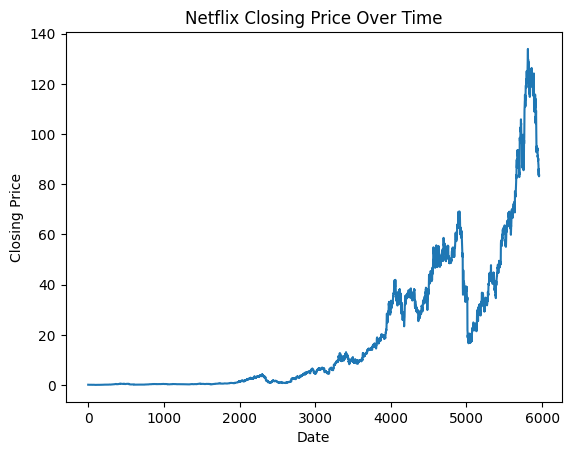


Daily Return Summary Statistics
count    5960.000000
mean        0.001697
std         0.034423
min        -0.409064
25%        -0.013617
50%         0.000347
75%         0.016215
max         0.422235
Name: Daily_Return, dtype: float64

Coefficient of Variation: 20.282762689204315
Skewness: 0.13084827016138847
Kurtosis: 19.312960867345147


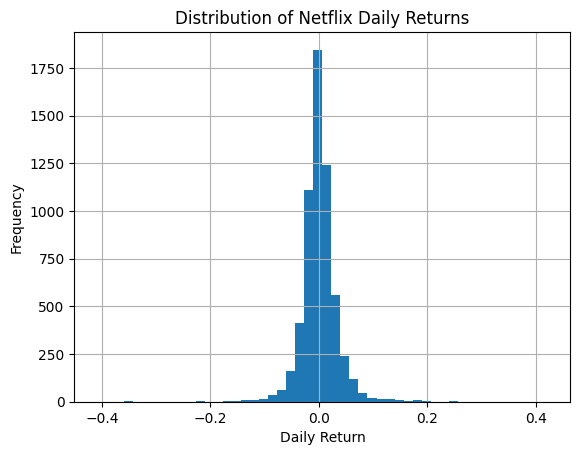

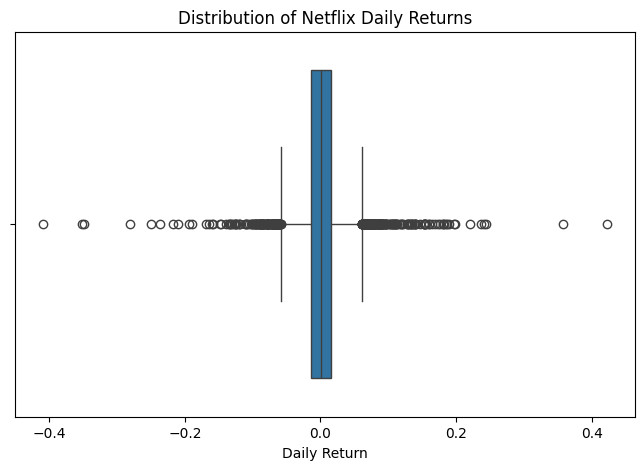

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daily Return Variable
df['Daily_Return'] = df['Close'].pct_change()

#Close Descriptive Statistics

#Mean
close_mean = df['Close'].mean()
#Median
close_median = df['Close'].median()

#Standard deviation 
close_std = df['Close'].std()
#Variance
close_variance = df['Close'].var()
#Range
close_range = df['Close'].max() - df['Close'].min()

# IQR
close_q1 = df['Close'].quantile(0.25)
close_q3 = df['Close'].quantile(0.75)
close_iqr = close_q3 - close_q1


# Skewness
close_skew = df['Close'].skew()
#kurtosis 
close_kurt = df['Close'].kurtosis()

#The Summary 
close_summary = df['Close'].describe()


print("Closing Price Summary Statistics")
print(close_summary)
print("\nCoefficient of Variation:", close_std / close_mean)
print("Skewness:", close_skew)
print("Kurtosis:", close_kurt, "\n")

#Plot
plt.figure()
df['Close'].plot()
plt.title("Netflix Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

#This plot show the overall direction of Netflix stock 
#It is volatile since it has drastic spikes and dips indicate periods of high market uncertainty
#This plot helps indentify price levls that the stock sturglles to break above or fall below 


#Daily Descriptive Statistic

# Central Tendency
return_mean = df['Daily_Return'].mean()
return_median = df['Daily_Return'].median()

#---------------------------------------------#

#Standard deviation 
return_std = df['Daily_Return'].std()
#Variance
return_variance = df['Daily_Return'].var()
#Range
return_range = df['Daily_Return'].max() - df['Daily_Return'].min()

# IQR
return_q1 = df['Daily_Return'].quantile(0.25)
return_q3 = df['Daily_Return'].quantile(0.75)
return_iqr = return_q3 - return_q1


# Skewness
return_skew = df['Daily_Return'].skew()
#kurtosis 
return_kurt = df['Daily_Return'].kurtosis()

#The Summary 
return_summary = df['Daily_Return'].describe()



print("\nDaily Return Summary Statistics")
print(return_summary)
print("\nCoefficient of Variation:", return_std / return_mean)
print("Skewness:", return_skew)
print("Kurtosis:",return_kurt)

#Histogram, Distribution of Continous Variable
plt.figure()
df['Daily_Return'].hist(bins=50)
plt.title("Distribution of Netflix Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()
#The distribution fo Daily return is centered around Zero, most reutrns are small with ocassional extrem positive and negative 
#The distribution shows evidence of heavy tails


#BoxPlot of Daily Return, Outliers
plt.figure(figsize=(8,5))
sns.boxplot(x= df["Daily_Return"],legend=False)

plt.title("Distribution of Netflix Daily Returns")
plt.xlabel("Daily Return")
plt.show()
#This box plot represents the itnerquartile range , which the vertical line inside the box are the media daily return values
#This was to show all the quartile ranges as well as the outliers of this data which represent extreme amrket events 
#Here, the outliers are numerous


# Bivariate Analysis 

Covariance Matrix:

                     Close        Volume          Open  Daily_Return
Close         7.761759e+02 -1.573269e+09  7.759437e+02     -0.007203
Volume       -1.573269e+09  3.319493e+16 -1.573507e+09 -69139.512094
Open          7.759437e+02 -1.573507e+09  7.760880e+02     -0.014686
Daily_Return -7.202746e-03 -6.913951e+04 -1.468638e-02      0.001185


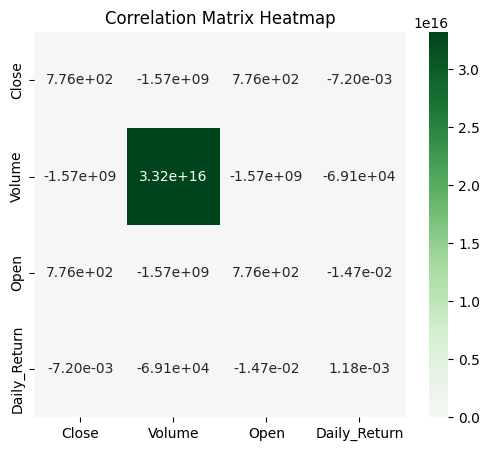


Correlation Matrix:

                 Close    Volume      Open  Daily_Return
Close         1.000000 -0.309947  0.999757     -0.007510
Volume       -0.309947  1.000000 -0.310011     -0.011046
Open          0.999757 -0.310011  1.000000     -0.015314
Daily_Return -0.007510 -0.011046 -0.015314      1.000000


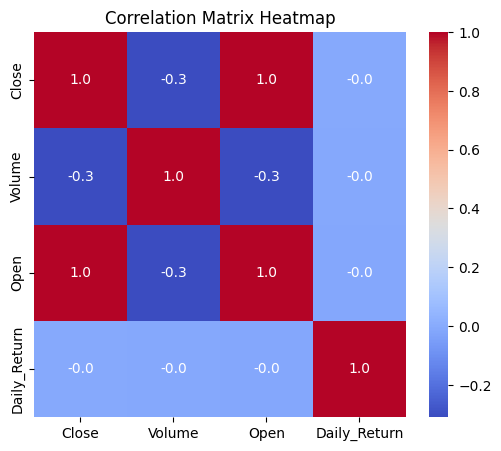

In [21]:
import seaborn as sns


#Covariance Matrix
Covariance_Matrix = df[['Close','Volume','Open','Daily_Return']].cov()
print("Covariance Matrix:\n")
print(Covariance_Matrix)

#Heatmap for Covariance Matrix
plt.figure(figsize=(6,5))
sns.heatmap(Covariance_Matrix, annot=True, cmap ='PRGn', fmt=".2e",
            center=0)

plt.title("Correlation Matrix Heatmap")
plt.show()

# Correlation Matrix (Pearson)
Correlation_Matrix = df[['Close','Volume','Open','Daily_Return']].corr()
print("\nCorrelation Matrix:\n")
print(Correlation_Matrix)
#Price variable move togehter closley meaning they are more volatile which mean they are less directly tied to other variables, thats why we cann see a huge amount of negative  values 

#Heatmap for Correlation Matrix
plt.figure(figsize=(6,5))
sns.heatmap(Correlation_Matrix, annot=True, cmap='coolwarm', fmt=".01f")

plt.title("Correlation Matrix Heatmap")
plt.show()
#Daily returns ar emore volatile and are less tied to other variables , which we can see and identify strong adn weak relationship


# Hypothesis Testing

# Hypothesis : Is Netflix’s average daily return significantly different from zero?

T-statistic: 3.8062386986150605
P-value: 0.00014251121549681514


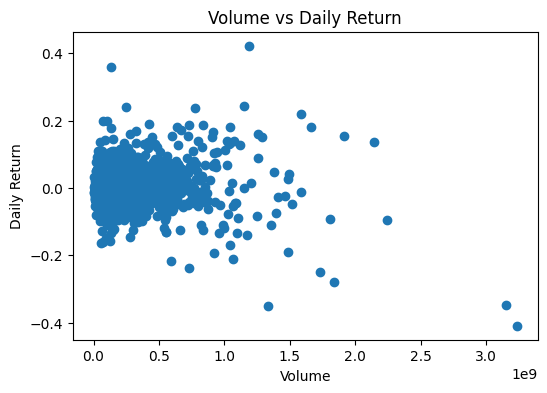

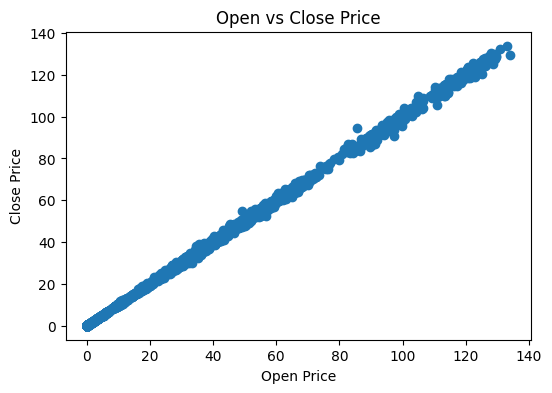

In [22]:
from scipy import stats

# Remove NaN values
returns = df['Daily_Return'].dropna()

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(returns, 0)

print("T-statistic:", t_stat)
print("P-value:", p_value)
#This is a one sample t-test which was to determine wethher the average daily return is signficantly different from 0.
#The result yiellded a statisitcally signficcantly value (p<0.05), meaning the daily return is signficantly different from zero 




#Behavior over Time
plt.figure(figsize=(6,4))
plt.scatter(df['Volume'], df['Daily_Return'])
plt.title("Volume vs Daily Return")
plt.xlabel("Volume")
plt.ylabel("Daily Return")
plt.show()
#This we can see that this data is clustered at lower levels with daily return being -0.1 and 0.1, also there are several highv volume outliers
# As volume increase, the vertical spread of the dots widens slightly,it idicates that higher trading volumes is asscoieted with higer price voaltilty 
#T-statistic (3.80) and P-value ( 0.00014) indicate that hte relationship between volume and daily return is stastitically signficant 

#Relationship between Open and Close VARIABLE 
plt.figure(figsize=(6,4))
plt.scatter(df['Open'], df['Close'])
plt.title("Open vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()
#This show that there is a nearly perfect staigh diagonal line, which means there is a strong relation between close and open variable ,
#The tight grouping suggest aht the price at the end of the day is close to where it started
#Also it idicates that there are few days wehre there is a massivve gap in prices
#Also there are not many outliers


# Relationships between the categorical and continuous variables 

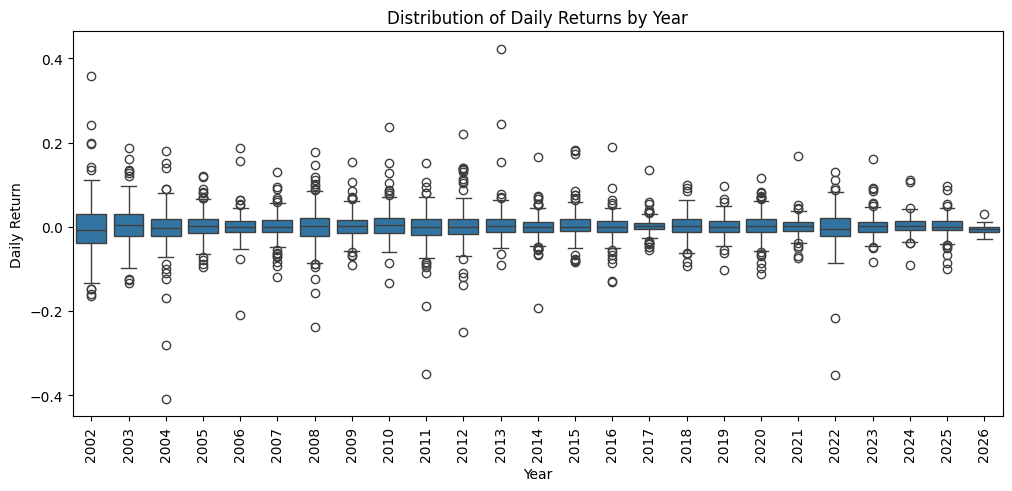

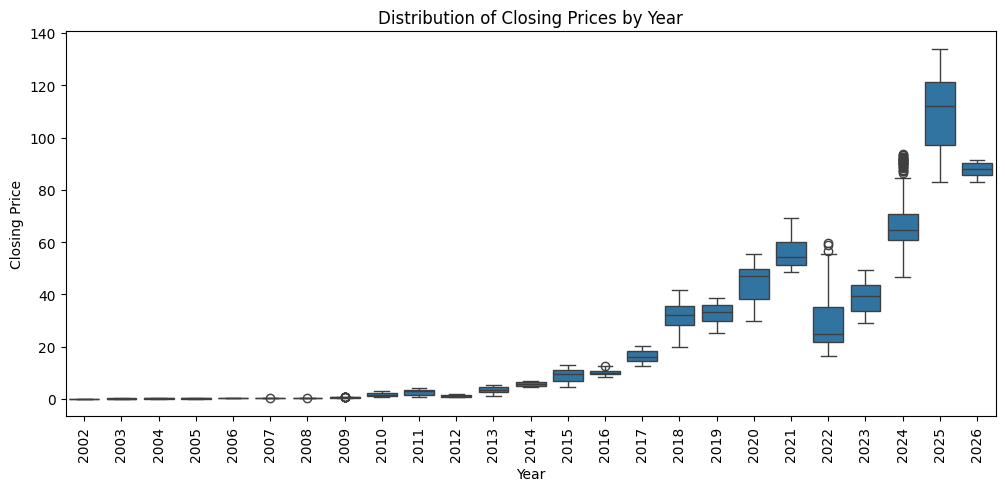

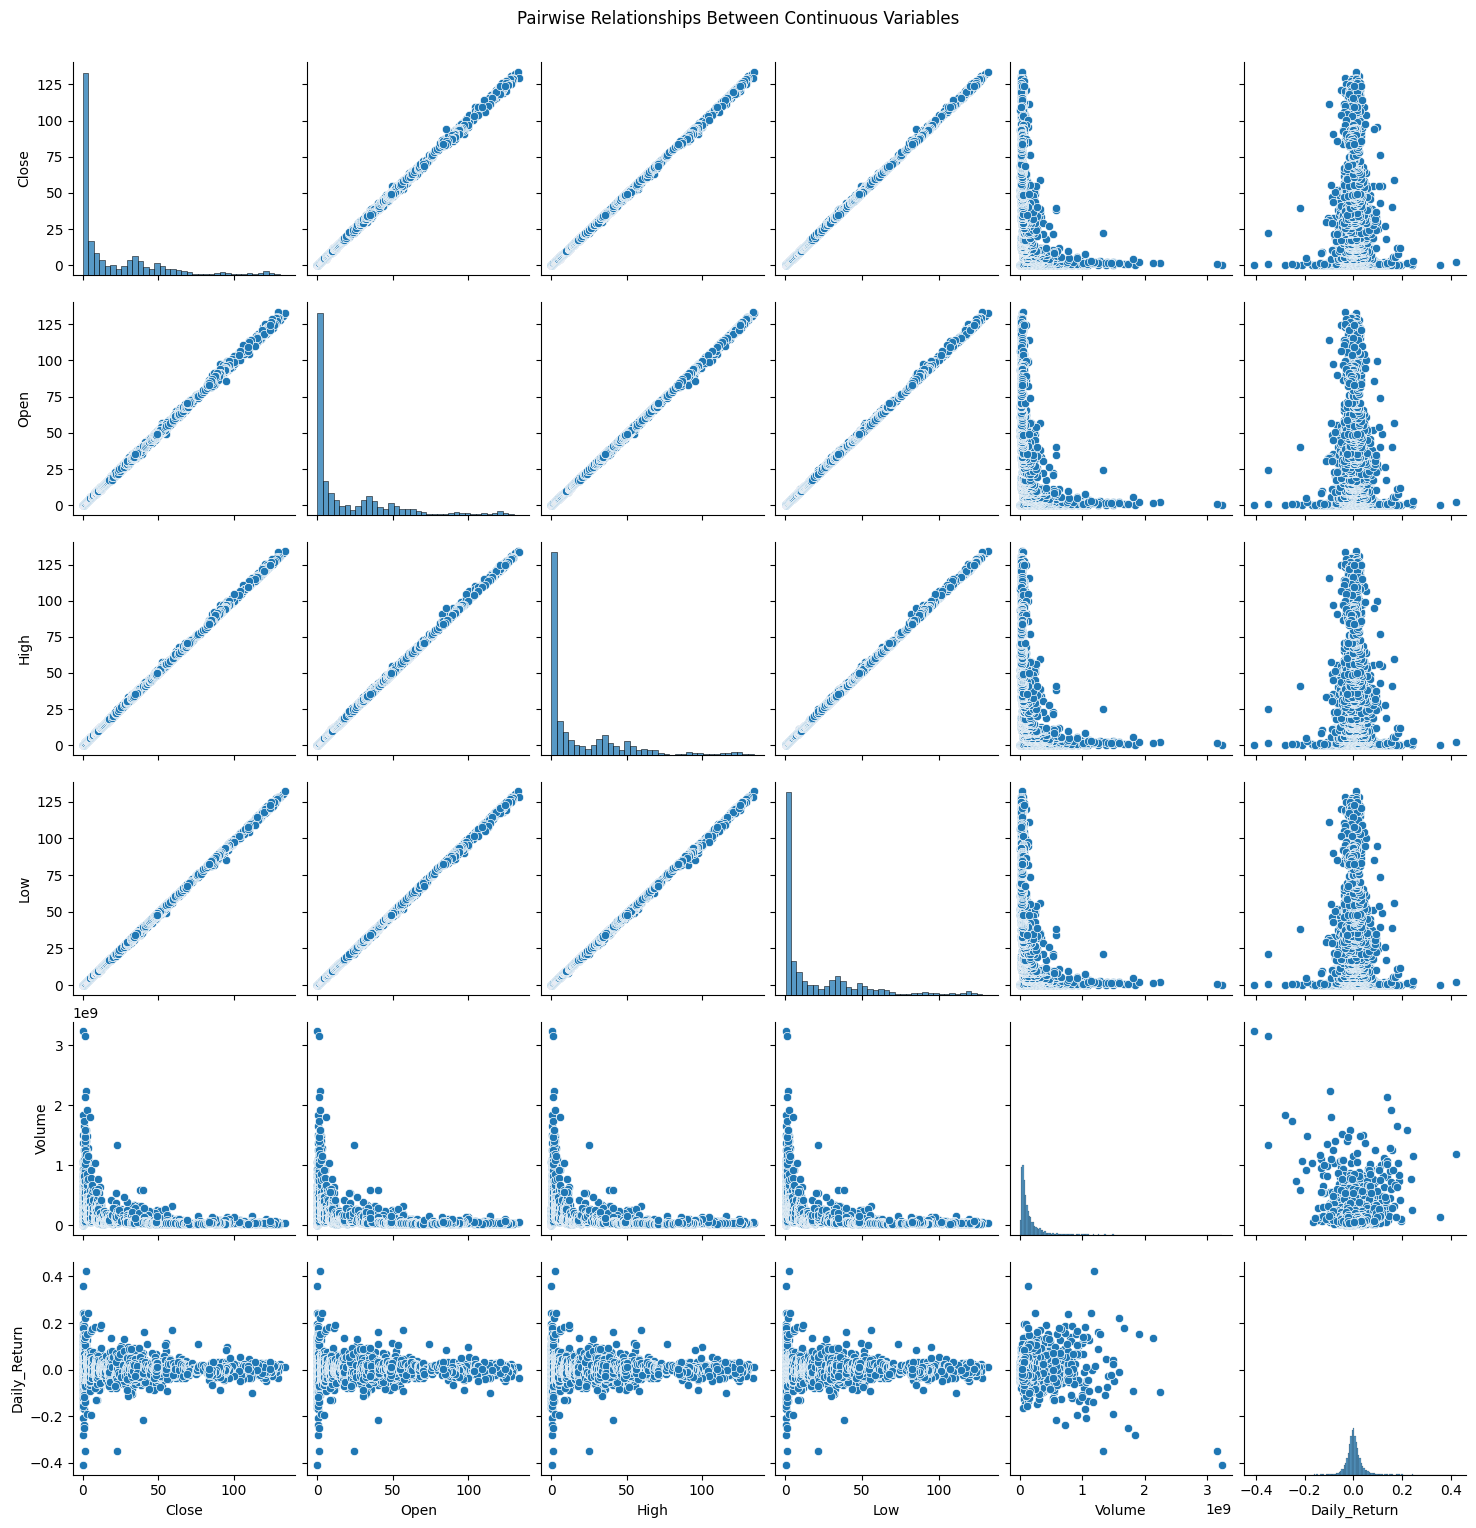

In [23]:
#Cateogrical Year Variable

df['Year']=df['Date'].dt.year


#Relantionship between Continous Variable and Categorical Variable
plt.figure(figsize=(12,5))
sns.boxplot(x='Year', y='Daily_Return', data=df)
plt.xticks(rotation=90) 
plt.title("Distribution of Daily Returns by Year")
plt.xlabel("Year")
plt.ylabel("Daily Return")
plt.show()
#This boxplot show how daily returns are distributed each year ,most years have return centered around 0 ,but some show higher volatility
#Outliers in both positive and negative return appea
#This box plot helps ups understadn hwo return behavior changes over the years 


#How continous values are dsitributed across the levels of a categorical variable 
plt.figure(figsize=(12,5))
sns.boxplot(x='Year', y='Close', data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Closing Prices by Year")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.show()
#This boxplot is to show low closign price,which we can see it higlight both growth trend and volatility over time 



#Explore correlation between continous Variables 

sns.pairplot(df[['Close', 'Open', 'High', 'Low', 'Volume', 'Daily_Return']])
plt.suptitle("Pairwise Relationships Between Continuous Variables", y=1.02)
plt.show()
#Here we can see the close,ope,high,and low prices are all storngly positively correlated  , and daily return has very weak correlataion with price chanigng
#Volume shwo no linear pattern with returns having some extrem spike  during market movemnets.

# Linear Regression and Machine Learning Approach 

In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df_model = df.dropna(subset=['Daily_Return']) #Get rid of all the NAN Values


#X AND Y
X= df_model[['Close', 'Open', 'High', 'Low', 'Volume']]
y= df_model['Daily_Return']

# The variables
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Intialize the type of regression
Linear_Regression = LinearRegression()
# Train the model 
Linear_Regression.fit(X_train,y_train)

#Prediction
y_pred = Linear_Regression.predict(X_test)

#MSE
MSE = mean_squared_error(y_test,y_pred)
# R^2
R2 = r2_score(y_test,y_pred)



print("---Linear Regression Results:---")
print("\nCoefficients: ", Linear_Regression.coef_)
print("\nIntercepts:", Linear_Regression.intercept_ )
print("\n Mean Squared Error:", MSE)
print("\n R-Squared :", R2)
print("-------------------------------- \n")

# The coefficeints are very small, which each feature a very tiny efect on Daily Return 
# R squared is 0.101, which means the model explains only 10% of the variance in daily return 
#The MSE is also very low 

# Machine Learning


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np


Random = RandomForestRegressor(n_estimators=100,random_state=42)

CV_Scores = cross_val_score(Random , X ,y , cv=5, scoring='r2' )

print("Random Forest Regression Results: \n")
print("Cross-Validated R-Squared Scores: ",CV_Scores )
print("Mean R-Squared :",np.mean(CV_Scores) )
#The R-Squares values vary widely



# Linear Regression and  Machine Learning approach produces very limited values in predictign the daily stock return 
# Meaning there is a lot of unpredictiability  on a short-term basis        

---Linear Regression Results:---

Coefficients:  [ 2.45227571e-02 -1.53924203e-02 -4.74442312e-03 -4.41691218e-03
 -8.75185838e-12]

Intercepts: 0.003686736211929563

 Mean Squared Error: 0.0012806087214650701

 R-Squared : 0.10144436771979004
-------------------------------- 

Random Forest Regression Results: 

Cross-Validated R-Squared Scores:  [ 2.82836616e-02  2.01532770e-03 -3.84005994e-01  1.03702874e-02
 -3.60355265e+00]
Mean R-Squared : -0.7893778729171245
